## Name        :           Rifaq Ajmal
## Reg No      :           23MDBCS435
## Section     :           A
## Subject     :           Ai Lab

## Example 1 : with the Penguins Dataset

In [3]:
import seaborn as sns
import pandas as pd

# Load Titanic dataset from Seaborn
df = sns.load_dataset('titanic')

# Display the first five rows of the dataset
print(df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## Example 2 : data processing with the Penguins Dataset

In [4]:
import seaborn as sns
import pandas as pd

# Load Penguins dataset from Seaborn
df = sns.load_dataset('penguins')

# Drop rows with missing target ('species') just to be safe
df = df.dropna(subset=['species'])

# Features (X): All columns except the species (target) column
X = df.drop('species', axis=1)

# Labels (y): The species column
y = df['species']

# Display the first five rows of features and labels
print("Features (X):")
print(X.head())

print("\nLabels (y):")
print(y.head())


Features (X):
      island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Torgersen            39.1           18.7              181.0       3750.0   
1  Torgersen            39.5           17.4              186.0       3800.0   
2  Torgersen            40.3           18.0              195.0       3250.0   
3  Torgersen             NaN            NaN                NaN          NaN   
4  Torgersen            36.7           19.3              193.0       3450.0   

      sex  
0    Male  
1  Female  
2  Female  
3     NaN  
4  Female  

Labels (y):
0    Adelie
1    Adelie
2    Adelie
3    Adelie
4    Adelie
Name: species, dtype: object


## Example 3: Check Missing Values in the Diamonds Dataset

In [5]:
import seaborn as sns
import pandas as pd

# Load the diamonds dataset
df = sns.load_dataset('diamonds')

# Check for missing values
missing_values = df.isnull().sum()

# Display the result
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


## Example 4: Boxplot Outlier Detection – Penguins Dataset

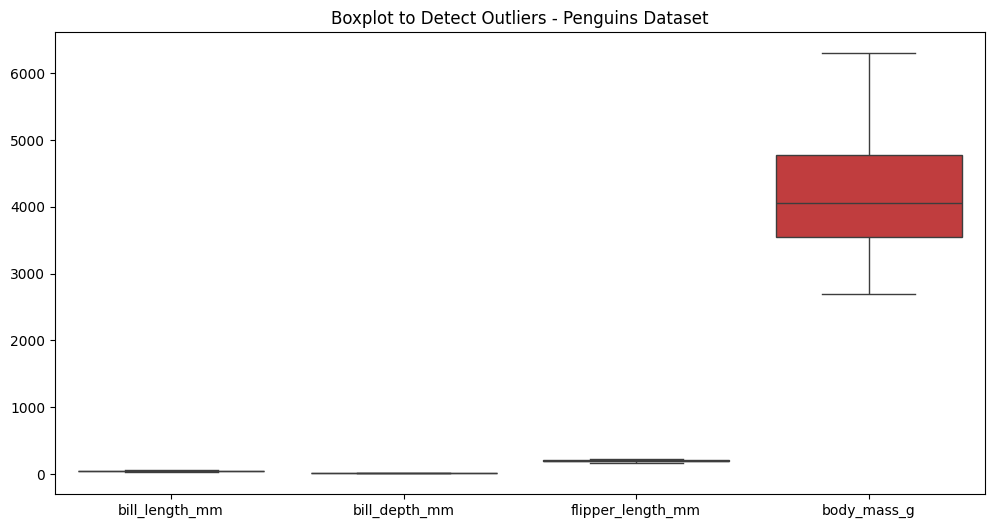

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load Penguins dataset
df = sns.load_dataset('penguins')

# Drop rows with missing values to avoid errors in boxplot
df = df.dropna()

# Visualize outliers using boxplots (exclude non-numeric + target column)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(['species', 'island', 'sex'], axis=1))
plt.title('Boxplot to Detect Outliers - Penguins Dataset')
plt.show()


## Example 5: Detect & Remove Outliers using IQR – Penguins Dataset

In [7]:
import seaborn as sns
import pandas as pd

# Load and clean the Penguins dataset
df = sns.load_dataset('penguins')
df = df.dropna()  # Drop rows with missing values

# Function to detect outliers using IQR
def detect_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (df < lower_bound) | (df > upper_bound)
    return outliers

# Detect outliers in numeric columns (excluding categorical and target)
numeric_df = df.drop(['species', 'island', 'sex'], axis=1)
outliers = detect_outliers(numeric_df)

# Print outlier summary
print("Outliers detected in each feature:")
print(outliers.sum())

# Remove rows with any outliers
df_cleaned = df[~(outliers.any(axis=1))]

print("\nOriginal dataset shape:", df.shape)
print("Cleaned dataset shape (after removing outliers):", df_cleaned.shape)


Outliers detected in each feature:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

Original dataset shape: (333, 7)
Cleaned dataset shape (after removing outliers): (333, 7)


## done bye teacher : We’ll use GaussianNB from the scikit-learn library to implement Naïve Bayes.
## Example 6: Naïve Bayes Classification – Penguins Dataset

In [9]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load and clean Penguins dataset
df = sns.load_dataset('penguins')
df = df.dropna()

# Select features and labels
X = df.drop(['species', 'island', 'sex'], axis=1)  # use only numeric features
y = df['species']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred = nb_model.predict(X_test)

# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Naïve Bayes Accuracy: {accuracy * 100:.2f}%")


Naïve Bayes Accuracy: 98.00%


## example 7 demonstrating the usage of GaussianNB with the Wine dataset:

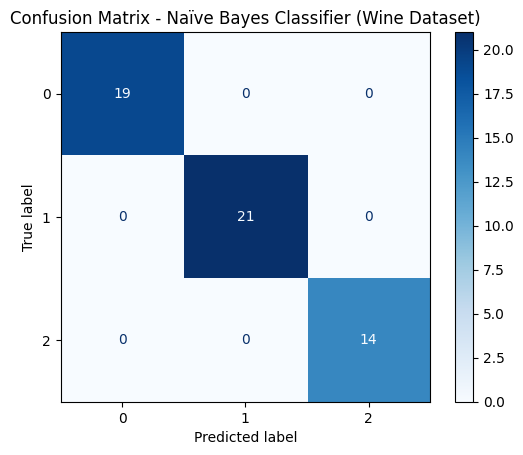

In [24]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Naïve Bayes model
nb_model = GaussianNB() # Corrected: Create an instance of GaussianNB
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_model.predict(X_test)

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Naïve Bayes Classifier (Wine Dataset)')
plt.show()